# Composable haze-style presets: data style + projection style

"Haze" is a value-modulated-opacity, glowing-rim visual style -- the recognisable look of ECMWF/CAMS
aerosol-forecast animations: an orthographic globe, two colour layers ("Organic Matter" smoke and
"Dust") that glow brightest at moderate density and fade to transparent at the edges, a chrome-free
black canvas, and plain white city labels. This notebook builds that look from cleopatra's building
blocks in [`cleopatra.colors`](../../reference/colors-glyph.md),
[`cleopatra.projection`](../../reference/projection.md), and [`cleopatra.geo`](../../reference/geo.md) --
and shows that every piece is **independently usable**, not bundled into one all-or-nothing preset.

Two independent axes compose the full look:

| axis | what it controls | primitives |
| --- | --- | --- |
| **data style** | colour + opacity + legend | `HAZE_COLORMAPS`, `alpha_scaled_image`/`_mesh`, `swatch_legend`, `apply_data_style` |
| **projection style** | coordinate frame | `orthographic_grid`/`_boundary`/`_graticule`, `apply_projection_style` |

Neither axis requires the other. By the end of this notebook you will have used the haze colours on a
flat map, the globe with plain colours, and the haze colours paired with the pre-existing `"ecmwf-dark"`
reference-map style -- three combinations the two-axis design makes possible for free.

## Setup

All data here is synthetic, generated in the notebook -- two Gaussian-blob fields on a 180x90 lon/lat
grid standing in for real "Organic Matter" and "Dust" aerosol forecasts.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from cleopatra.colors import HAZE_COLORMAPS, alpha_scaled_image, alpha_scaled_mesh, apply_data_style
from cleopatra.projection import apply_projection_style
from cleopatra.styles import apply_blank_canvas
from cleopatra.geo import add_point_labels

### A synthetic two-layer aerosol field

A smoke plume ("organic_matter") drifting from Canada toward Europe, and a dust plume ("dust") over
the North Atlantic -- each a Gaussian blob on a lon/lat grid, values in `[0, 1]`.

In [2]:
lon = np.linspace(-180, 180, 180)
lat = np.linspace(-90, 90, 90)
lon_grid, lat_grid = np.meshgrid(lon, lat)

def blob(center_lon, center_lat, spread_deg):
    """A blob that is actually circular on the sphere (great-circle distance)."""
    lon0, lat0 = np.radians(center_lon), np.radians(center_lat)
    lon_r, lat_r = np.radians(lon_grid), np.radians(lat_grid)
    cos_c = np.sin(lat0) * np.sin(lat_r) + np.cos(lat0) * np.cos(lat_r) * np.cos(lon_r - lon0)
    angular_deg = np.degrees(np.arccos(np.clip(cos_c, -1, 1)))
    return np.exp(-(angular_deg ** 2) / (2 * spread_deg ** 2))

organic_matter = blob(-30, 65, 20) * 0.9
dust = blob(-20, 30, 15) * 0.85
organic_matter.shape, dust.shape

((90, 180), (90, 180))

## Quickstart -- the full haze look in two calls

`apply_projection_style` reprojects the grid onto an orthographic globe and frames it; the `(x, y,
data)` it returns feeds straight into `apply_data_style`, which draws both colour layers and their
swatch legends. `apply_blank_canvas` strips the axes down to the chrome-free black look.

Both layers share the same grid and globe, so the boundary/graticule only need to be drawn once:
the first call uses the default `draw_frame=True`, and every call after that passes
`draw_frame=False` to reproject/mask its own layer without redrawing (and duplicating) the chrome.

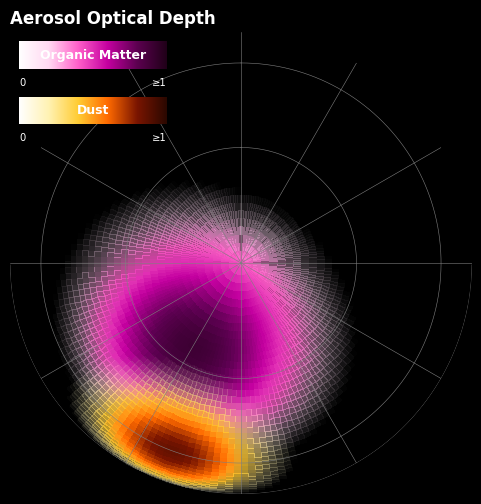

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
apply_blank_canvas(ax)

x, y, om_masked = apply_projection_style(ax, lon, lat, organic_matter, style='globe')
_, _, dust_masked = apply_projection_style(
    ax, lon, lat, dust, style='globe', draw_frame=False
)

images = apply_data_style(ax, {'organic_matter': om_masked, 'dust': dust_masked}, x=x, y=y)
ax.set_title('Aerosol Optical Depth', color='white', loc='left', fontweight='bold')
plt.show()

That single figure reproduces the haze look (the ECMWF/CAMS aerosol-animation aesthetic): a globe,
two fading colour layers, and their
labelled swatches -- built entirely from generic primitives, none of which know about each other.

## The data-style axis alone -- no globe at all

`apply_data_style` doesn't know or care whether it's drawing on a globe. Passing no `x`/`y` renders
the same two layers with plain `imshow` on a regular flat axes. Pass `extent=[west, east, south, north]`
and `origin="lower"` (forwarded straight through to `imshow`) so the axes are in real lon/lat degrees
with north at the top -- needed for anything else plotted afterwards (e.g. city markers) to line up.

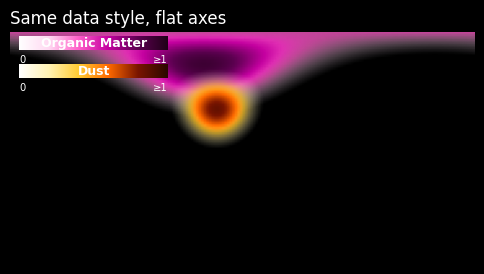

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
apply_blank_canvas(ax)
apply_data_style(
    ax, {'organic_matter': organic_matter, 'dust': dust},
    extent=[-180, 180, -90, 90], origin='lower',
)
ax.set_title('Same data style, flat axes', color='white', loc='left')
plt.show()

## The projection-style axis alone -- no haze colours

Just as independently, the globe projection works with any colouring. Here a single plain `viridis`
layer is drawn on the globe via `alpha_scaled_mesh` directly, with no `apply_data_style` involved.

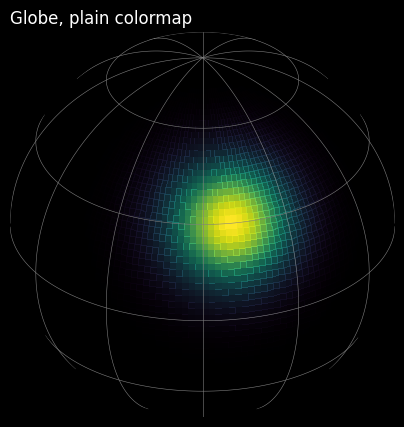

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
apply_blank_canvas(ax)
x, y, masked = apply_projection_style(ax, lon, lat, dust, style='globe', center_lat=30.0, center_lon=-30.0)
alpha_scaled_mesh(ax, x, y, masked, 'viridis')
ax.set_title('Globe, plain colormap', color='white', loc='left')
plt.show()

## Mixing the haze data style with the existing ECMWF reference map

`apply_data_style` composes with styling from earlier work too -- here the haze colour layers sit on
top of the pre-existing ECMWF coastline/graticule preset
([`GeoMixin.add_reference_map`](../../reference/geo.md)) instead of the globe, using `style="flat"`
from `apply_projection_style` as a pure pass-through. `add_reference_map("auto")` picks the
`"ecmwf"` (dark coastlines) or `"ecmwf-dark"` (light coastlines) variant by sampling the backdrop's
own displayed luminance -- always the right pick regardless of what colour the backdrop turns out to be.

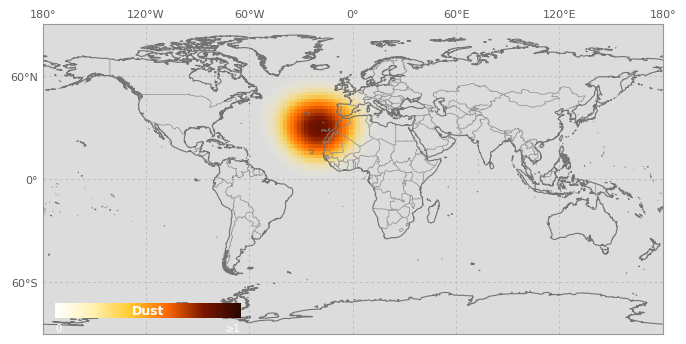

In [6]:
from cleopatra.array_glyph import ArrayGlyph

backdrop = np.zeros_like(lon_grid)  # a blank field, just to host the reference map
glyph = ArrayGlyph(backdrop, extent=[-180, -90, 180, 90])
fig, ax = glyph.plot()
glyph.cbar.remove()  # drop the blank backdrop's own colorbar; keep the swatch legend only
glyph.add_reference_map('auto')

x, y, out = apply_projection_style(ax, lon, lat, dust, style='flat')
apply_data_style(ax, {'dust': out}, x=x, y=y, legend_bounds=[(0.02, 0.05, 0.3, 0.05)])
plt.show()

## City labels

`add_point_labels` (or the `GeoMixin.add_labels` glyph method) draws the plain dot-and-text city
labels ECMWF/CAMS maps use, independent of everything above -- it just needs coordinates in whatever
space the axes is already using. Here that space is real lon/lat degrees (thanks to the `extent`
above), so city coordinates can be passed straight through unmodified; on the globe they would need
reprojecting first with `orthographic_points` (see the animation below).

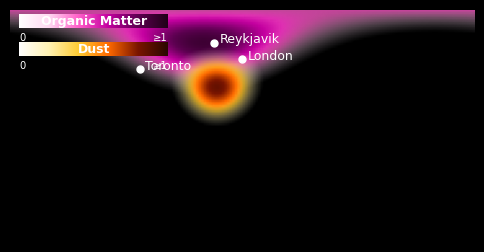

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
apply_blank_canvas(ax)
apply_data_style(
    ax, {'organic_matter': organic_matter, 'dust': dust},
    extent=[-180, 180, -90, 90], origin='lower',
)
add_point_labels(ax, {
    'London': (-0.1, 51.5),
    'Reykjavik': (-21.9, 64.1),
    'Toronto': (-79.4, 43.7),
})
plt.show()

## Chrome comparison: `apply_blank_canvas` vs. the default axes

`apply_blank_canvas` is itself a standalone, generic primitive -- a plain flat plot looks like this
with and without it.

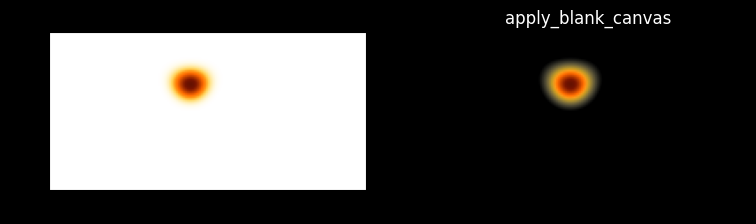

In [8]:
extent = [-180, 180, -90, 90]
fig, (ax_default, ax_blank) = plt.subplots(1, 2, figsize=(9, 3.5))
apply_data_style(ax_default, {'dust': dust}, extent=extent, origin='lower', legend=False)
ax_default.set_title('default axes')

apply_data_style(ax_blank, {'dust': dust}, extent=extent, origin='lower', legend=False)
apply_blank_canvas(ax_blank)
ax_blank.set_title('apply_blank_canvas', color='white')
plt.show()

## Animating a multi-day forecast loop

The style this notebook builds comes from ECMWF/CAMS **animations** -- a multi-day aerosol forecast
playing as a loop, with the plumes drifting across a fixed globe view and the date advancing in the
title. This section builds exactly that, combining every piece from above: `apply_projection_style`
redrawn per frame, `apply_data_style` for the colour layers, `apply_blank_canvas` for the chrome-free
look, city labels, and [`cleopatra.animation.to_gif`](../../reference/animation.md) to export it.

### Reproject the city points once

The city markers stay fixed across every frame (only the plumes move), so `orthographic_points`
only needs to run once, before the animation loop -- reprojecting it per frame would be wasted work.
Points on the far hemisphere come back `NaN`; drop those before plotting.

In [9]:
from cleopatra.projection import orthographic_points

view_lat, view_lon = 55.0, -30.0  # mid-Atlantic view, matching the plumes below
cities = {'London': (-0.1, 51.5), 'Reykjavik': (-21.9, 64.1), 'Toronto': (-79.4, 43.7)}
city_lon = np.array([lon for lon, lat in cities.values()])
city_lat = np.array([lat for lon, lat in cities.values()])
cx, cy = orthographic_points(city_lon, city_lat, center_lat=view_lat, center_lon=view_lon)
projected_cities = {name: (x, y) for name, x, y in zip(cities, cx, cy) if np.isfinite(x)}

### One frame, redrawn each day

Each frame clears the axes and redraws everything from scratch -- the boundary, graticule, colour
layers, and swatch legends are all freshly created artists on every call, so a full redraw (rather
than updating individual artists in place) is the simplest correct way to animate this composition.
The two plumes drift independently: `organic_matter` sweeps from Canada toward Europe, `dust` drifts
across the mid-Atlantic -- the same west-to-east transport the real CAMS forecasts track.

In [10]:
def animate(day):
    ax.clear()
    apply_blank_canvas(ax)
    om_t = blob(-95 + day * 8, 60, 16) * 0.9
    dust_t = blob(-70 + day * 8, 25, 14) * 0.85
    x, y, om_m = apply_projection_style(
        ax, lon, lat, om_t, style='globe', center_lat=view_lat, center_lon=view_lon
    )
    _, _, dust_m = apply_projection_style(
        ax, lon, lat, dust_t, style='globe',
        center_lat=view_lat, center_lon=view_lon, draw_frame=False,
    )
    apply_data_style(ax, {'organic_matter': om_m, 'dust': dust_m}, x=x, y=y)
    add_point_labels(ax, projected_cities, fontsize=7, marker_size=3)
    ax.set_title(f'Aerosol Optical Depth -- Day {day + 1}', color='white', loc='left', fontweight='bold')

### Render and embed

`FuncAnimation` drives `animate` once per day; `to_gif` renders it to GIF bytes the same way
`save_animation`/`to_gif` do for any matplotlib animation (see the
[animation quality-controls notebook](../animation/animation_examples.ipynb)), and `Image` embeds
those bytes inline.

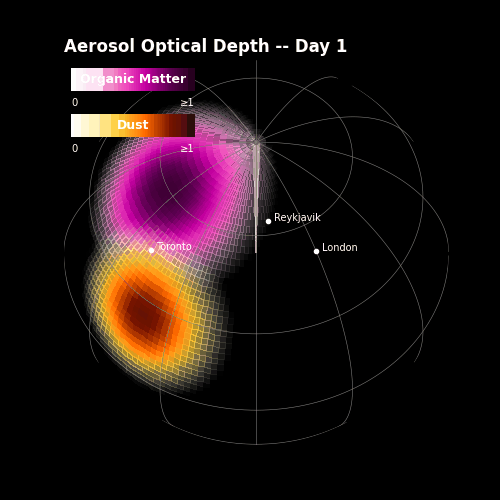

In [11]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image
from cleopatra.animation import to_gif

fig, ax = plt.subplots(figsize=(5, 5))
anim = FuncAnimation(fig, animate, frames=12, interval=300)
gif_bytes = to_gif(anim, fps=4)
plt.close(fig)
Image(gif_bytes)

## Takeaway

- `apply_data_style` (colour + alpha + legend) and `apply_projection_style` (globe/flat framing) are
  independent axes -- pick either, both, or neither.
- Every primitive underneath (`HAZE_COLORMAPS`, `alpha_scaled_image`/`_mesh`, `swatch_legend`,
  `apply_blank_canvas`, `orthographic_grid`/`_boundary`/`_graticule`/`_points`, `add_point_labels`) is
  a plain function usable on its own, with any other colormap, projection, or cleopatra styling.
- The `"haze"` and `"globe"` names are just convenience presets over those primitives -- the same
  presets compose with prior work like the `"ecmwf"`/`"ecmwf-dark"` reference-map style.
- The same primitives redrawn per frame with `FuncAnimation` and exported with `to_gif` reproduce the
  real ECMWF/CAMS multi-day forecast loop this style is modelled on.